# Import Required Python Library

In [9]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table

## Additional on top of Lab-2
import seaborn as sns
from pyspark.sql.window import Window
import utils.data_processing_silver_clickstream_table
import utils.data_processing_silver_attributes_table
import utils.data_processing_silver_financials_table

# Set Up pyspark Session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/29 11:53:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Read All CSV from Assignment-1

## 1. lms_loan_daily.csv

### 1.1 Read the CSV and infer the schema, not needed schema infer in parquet file

In [3]:
df_lms = spark.read.csv("data/lms_loan_daily.csv", header=True, inferSchema=True)
df_lms.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|CUS_0x1000_2023_0...| CUS_0x1000|     2023-05-01|    10|              0|   10000|    0.0|     0.0|        0.0|10000.0|   2023-05-01|
|CUS_0x1000_2023_0...| CUS_0x1000|     2023-05-01|    10|              1|   10000| 1000.0|  1000.0|        0.0| 9000.0|   2023-06-01|
|CUS_0x1000_2023_0...| CUS_0x1000|     2023-05-01|    10|              2|   10000| 1000.0|  1000.0|        0.0| 8000.0|   2023-07-01|
|CUS_0x1000_2023_0...| CUS_0x1000|     2023-05-01|    10|              3|   10000| 1000.0|     0.0|     1000.0| 8000.0|   2023-08-01|
|CUS_0x1000_2023_0...| CUS_0x1000|     2023-05-01|    10|     

In [18]:
df_lms.select("loan_id").show(truncate=False) # just trying to understand the loan_id

+---------------------+
|loan_id              |
+---------------------+
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1000_2023_05_01|
|CUS_0x1009_2025_01_01|
|CUS_0x1009_2025_01_01|
|CUS_0x1009_2025_01_01|
|CUS_0x1009_2025_01_01|
|CUS_0x1009_2025_01_01|
|CUS_0x1009_2025_01_01|
|CUS_0x1009_2025_01_01|
|CUS_0x1009_2025_01_01|
|CUS_0x1009_2025_01_01|
+---------------------+
only showing top 20 rows



In [26]:
df_lms.select("*").count() # trying to understand of how many rows the dataset

137500

In [27]:
df_lms.select("*").distinct().count() # trying to understand whether there's duplication

137500

In [29]:
df_lms.select("snapshot_date").distinct().count() # trying to understand how many snapshot date that we have

35

In [72]:
df_lms.select("loan_start_date").distinct().count() # trying to understand how many loan_start_date that we have

25

In [75]:
df_lms.select("Customer_ID").distinct().count() # trying to understand how many customer_id

12500

### 1.2 Understanding the infered schema data type

In [36]:
df_lms.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: integer (nullable = true)
 |-- due_amt: double (nullable = true)
 |-- paid_amt: double (nullable = true)
 |-- overdue_amt: double (nullable = true)
 |-- balance: double (nullable = true)
 |-- snapshot_date: date (nullable = true)



### 1.3 Checking empty string, nan, and null from each column

In [20]:
missing_counts = df_lms.select([
    F.count(
        F.when(F.isnan(c) | F.col(c).isNull(), c) 
        if dtype in ("double", "float") 
        else F.when(
            F.col(c).isNull() | (F.trim(F.col(c)) == "") | (F.lower(F.col(c)) == "null"), 
            c
        ) if dtype == "string"
        else F.when(F.col(c).isNull(), c)
    ).alias(c)
    for c, dtype in df_lms.dtypes
])

missing_counts.show(truncate=False)


+-------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|
+-------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|0      |0          |0              |0     |0              |0       |0      |0       |0          |0      |0            |
+-------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+



### 1.4 Mini EDA

In [28]:
# Detailed statistical summary including percentiles
df_lms.select("tenure", "installment_num", "loan_amt", "due_amt", "paid_amt", "overdue_amt", "balance").summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

[Stage 19:>                                                         (0 + 3) / 3]

+-------+------+-----------------+--------+------------------+------------------+------------------+-----------------+
|summary|tenure|  installment_num|loan_amt|           due_amt|          paid_amt|       overdue_amt|          balance|
+-------+------+-----------------+--------+------------------+------------------+------------------+-----------------+
|  count|137500|           137500|  137500|            137500|            137500|            137500|           137500|
|   mean|  10.0|              5.0| 10000.0| 909.0909090909091|  711.810909090909| 871.9054545454545|5871.905454545455|
| stddev|   0.0|3.162289159422599|     0.0|287.48083267477995|485.72685937838196|2002.6725443189466|3070.777574545779|
|    min|    10|                0|   10000|               0.0|               0.0|               0.0|              0.0|
|    25%|    10|                2|   10000|            1000.0|               0.0|               0.0|           3000.0|
|    50%|    10|                5|   10000|     

##### Few observations:
##### 1. Just like the study case in class, the tenure is uniform on 10 years. Similar with loan_amt at 10,000
##### 2. Installment number is expected to show sequence of payment, 10x installemnt
##### 3. Due_amt is typically 1,000 as loan divided by 10x payment
##### 4. From the paid_amt, we can see that most intallment paid on the schedule 1,000 up tp 75th percentile. However maximum paid_amt reached 4,000. that could means some borrowers make lump-sum advance payments or pay off back-dues all at once
##### 5. Over 75% of the entries have 0.0 due amounts, but there's tail data showing overdue_amt reaches maximum of 10,000 that can be translated some borrowers failed to pay anything.

## 1.5 EDA (Finding Stable Period)

In [46]:
# 1. Define Months on Book (MOB) based on hint in the classroom
df_lms2 = df_lms.withColumn("mob", F.col("installment_num"))

# 2. Flag default when we detect overdue_amt > 0
df_lms2 = df_lms2.withColumn("is_default_now", F.when(F.col("overdue_amt") > 0, 1).otherwise(0))

# 3. Calculate cumulative "ever defaulted" status up to that MOB per loan
loan_window = (
    Window.partitionBy("loan_id")
    .orderBy("mob")
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
)

df_lms2 = df_lms2.withColumn("ever_defaulted", F.max("is_default_now").over(loan_window)) # The new column

# Verify
df_lms2.select("loan_id", "mob", "is_default_now", "ever_defaulted").show(truncate=False) 

+---------------------+---+--------------+--------------+
|loan_id              |mob|is_default_now|ever_defaulted|
+---------------------+---+--------------+--------------+
|CUS_0x1000_2023_05_01|0  |0             |0             |
|CUS_0x1000_2023_05_01|1  |0             |0             |
|CUS_0x1000_2023_05_01|2  |0             |0             |
|CUS_0x1000_2023_05_01|3  |1             |1             |
|CUS_0x1000_2023_05_01|4  |0             |1             |
|CUS_0x1000_2023_05_01|5  |1             |1             |
|CUS_0x1000_2023_05_01|6  |1             |1             |
|CUS_0x1000_2023_05_01|7  |1             |1             |
|CUS_0x1000_2023_05_01|8  |1             |1             |
|CUS_0x1000_2023_05_01|9  |1             |1             |
|CUS_0x1000_2023_05_01|10 |1             |1             |
|CUS_0x1009_2025_01_01|0  |0             |0             |
|CUS_0x1009_2025_01_01|1  |0             |0             |
|CUS_0x1009_2025_01_01|2  |0             |0             |
|CUS_0x1009_20

In [59]:
# Create Group of Month-Year (YYYY-MM)
df_lms2 = df_lms2.withColumn("loan_month_year", F.date_format("loan_start_date", "yyyy-MM"))

# Aggregate overall cumulative default rate by MOB
overall_rate = (
    df_lms2.groupBy("mob")
    .agg(
        F.countDistinct("loan_id").alias("total_loans"),
        F.avg("ever_defaulted").alias("cumulative_default_rate") # What's the average of default per MOB?
    )
    .orderBy("mob")
    .toPandas()
)

# Aggregate by cohort and MOB
cohort_rate = (
    df_lms2.groupBy("loan_month_year", "mob")
    .agg(F.avg("ever_defaulted").alias("cumulative_default_rate"))
    .orderBy("loan_month_year", "mob")
    .toPandas()
)

# Verify (don't forget to comment .toPandas())
#overall_rate.show()
#cohort_rate.show()

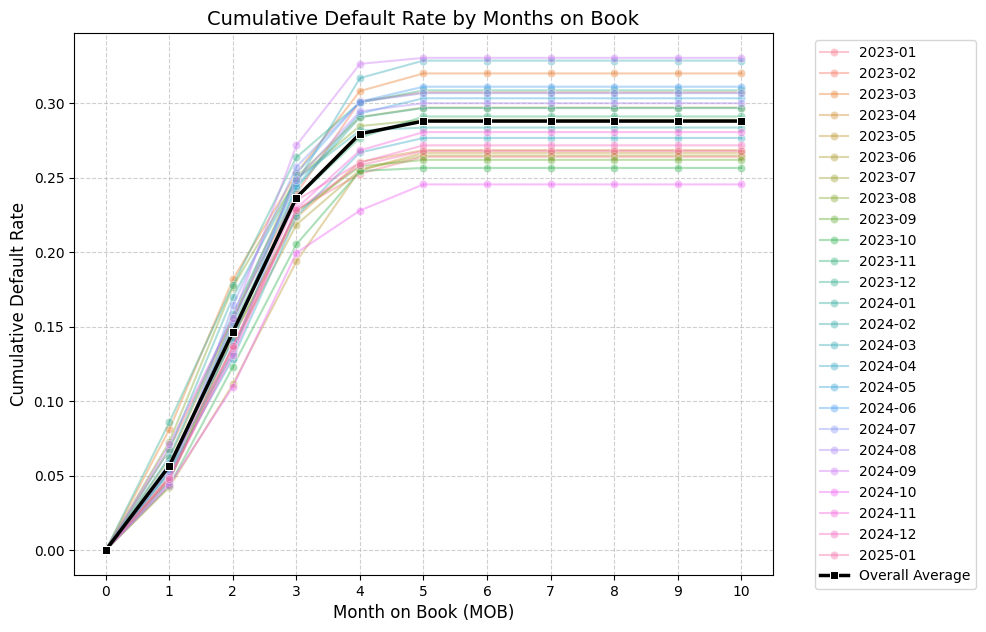

In [63]:
plt.figure(figsize=(10, 6.5))

# Plot loan_month_year Curves
sns.lineplot(
    data=cohort_rate, 
    x="mob", 
    y="cumulative_default_rate", 
    hue="loan_month_year", 
    marker="o", 
    alpha=0.4
)

# Plot Overall Average Curve
sns.lineplot(
    data=overall_rate, 
    x="mob", 
    y="cumulative_default_rate", 
    color="black", 
    linewidth=2.5, 
    marker="s", 
    label="Overall Average"
)

plt.title("Cumulative Default Rate by Months on Book", fontsize=14)
plt.xlabel("Month on Book (MOB)", fontsize=12)
plt.ylabel("Cumulative Default Rate", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(range(0, int(overall_rate["mob"].max()) + 1))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Summary:
#### 1. The cummulative default rate stabilizes completely at MOB 5, safely used MOB 6 - 30 DPD on existing code from lab-2
#### 2. It's 30 days past due as flag overdue was given when overdue_amt > 0
#### 3. Two flags: is_default_now and ever_default to track a customer that return to pay the installment but keep tracked that the customer has historical of default

## 2. feature_clickstream.csv

In [30]:
df_click = spark.read.csv("data/feature_clickstream.csv", header=True, inferSchema=True)
df_click.show()

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|  63| 118|  80| 121|  55| 193| 111| 112|-101|   83|  164|  105|  -16|  -81| -126|  114|   35|   85|  -73|   76| CUS_0x1037|   2023-01-01|
|-108| 182| 123|   4| -56|  27|  25|  -6| 284|  222|  203|  190|  -14|  -96|  200|   35|  130|   94|  111|   75| CUS_0x1069|   2023-01-01|
| -13|   8|  87| 166| 214| -98| 215| 152| 129|  139|   14|  203|   26|   86|  171|  125| -130|  354|   17|  302| CUS_0x114a|   2023-01-01|
| -85|  45| 200|  89| 128|  54|  76|  51|  61|  139|    6|  197|  172|   96|  174|  163|   37|  207|  180|  118| CUS_0x1184|   2023-01-01|
|  55| 120| 226| -86| 253| 

In [68]:
df_click.select("*").count() # trying to understand of how many rows the dataset

215376

In [70]:
df_click.select("*").distinct().count() # trying to understand whether there's duplication

215376

In [71]:
df_click.select("snapshot_date").distinct().count() # trying to understand how many snapshot date that we have

24

In [73]:
df_click.select("Customer_ID").distinct().count() # trying to understand how many snapshot date that we have

8974

### 2.2 Understanding the infered schema data type

In [76]:
df_click.printSchema()

root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



### 2.3 Checking empty string, nan, and null from each column

In [79]:
missing_counts = df_click.select([
    F.count(
        F.when(F.isnan(c) | F.col(c).isNull(), c) 
        if dtype in ("double", "float", "integer") 
        else F.when(
            F.col(c).isNull() | (F.trim(F.col(c)) == "") | (F.lower(F.col(c)) == "null"), 
            c
        ) if dtype == "string"
        else F.when(F.col(c).isNull(), c)
    ).alias(c)
    for c, dtype in df_click.dtypes
])

missing_counts.show(truncate=False)

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|0   |0   |0   |0   |0   |0   |0   |0   |0   |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0          |0            |
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+



## 2.4 Mini EDA

In [90]:
# Detailed statistical summary including percentiles
# Select features, run summary, convert to Pandas, and transpose
cols = [f"fe_{i}" for i in range(1, 21)]
summary_transposed = (
    df_click.select(cols)
    .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
    .toPandas()
    .set_index("summary")
    .transpose()
)

summary_transposed

summary,count,mean,stddev,min,25%,50%,75%,max
fe_1,215376,101.41479552039225,99.83359392844184,-378,34,102,169,541
fe_2,215376,103.09619456206819,99.93000203749298,-356,36,103,170,560
fe_3,215376,104.33370941980536,100.59986549187705,-399,36,104,172,583
fe_4,215376,105.64850308298047,100.32606477046183,-307,38,106,173,562
fe_5,215376,106.99667558130896,100.69360665858557,-343,39,107,175,570
fe_6,215376,103.23592229403462,100.27038751891193,-321,36,103,171,565
fe_7,215376,107.0703374563554,100.32326515826574,-368,39,107,174,537
fe_8,215376,110.71872446326425,100.24369781781921,-361,43,111,179,573
fe_9,215376,114.40635446846446,100.18613852691671,-328,47,115,182,577
fe_10,215376,117.77579674615556,100.80768608991778,-317,50,118,186,537


### Summary on feature_clickstream
1. The number of rows in lms_loan_daily.csv has 137,500 lines while the clickstream has 215,376 (confirm no duplication)
2. If join table is required will be based on "Customer_ID" and "snapshot_date"
3. First glance, the data doesn't look meaningful
4. Interestingly the snapshot_date is less than lms_loan_daily.csv
5. Seems the snapshot_date in clickstreams is equal with loan_start_date in lms_loan_daily, assume that's the user activity on web during loan being granted
6. Number of customer_id is only 8,974 compared to 12,500 in loan_start_date
7. Looking at the mean and std seems all fe_x in the same range and distribution
8. No idea what's the fe actually captured
9. No data cleaning required

## 3. features_attributes.csv

In [31]:
df_attr = spark.read.csv("data/features_attributes.csv", header=True, inferSchema=True)
df_attr.show()

+-----------+-----------------+---+-----------+-------------+-------------+
|Customer_ID|             Name|Age|        SSN|   Occupation|snapshot_date|
+-----------+-----------------+---+-----------+-------------+-------------+
| CUS_0x1000|   Alistair Barrf| 18|913-74-1218|       Lawyer|   2023-05-01|
| CUS_0x1009|           Arunah| 26|063-67-6938|     Mechanic|   2025-01-01|
| CUS_0x100b|         Shirboni| 19|  #F%$D@*&8|Media_Manager|   2024-03-01|
| CUS_0x1011|        Schneyerh| 44|793-05-8223|       Doctor|   2023-11-01|
| CUS_0x1013|         Cameront| 44|930-49-9615|     Mechanic|   2023-12-01|
| CUS_0x1015|          Holtono| 27|810-97-7024|   Journalist|   2023-08-01|
| CUS_0x1018|      Felsenthalq| 15|731-19-8119|   Accountant|   2023-11-01|
| CUS_0x1026|          Josephv| 52|500-62-9044|      Manager|   2023-10-01|
| CUS_0x102d| Neil Chatterjeex| 31|692-71-7552| Entrepreneur|   2024-01-01|
| CUS_0x102e|            Rhysn| 26|  #F%$D@*&8|    Scientist|   2024-04-01|
| CUS_0x1032

In [93]:
df_attr.printSchema() # apparently all string

root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



In [94]:
df_attr.select("*").count() # trying to understand of how many rows the dataset

12500

In [96]:
df_attr.select("Customer_ID").distinct().count() # trying to understand whether there's duplication

12500

### 3.1 Checking empty string, nan, and null from each column

In [98]:
missing_counts = df_attr.select([
    F.count(
        F.when(F.isnan(c) | F.col(c).isNull(), c) 
        if dtype in ("double", "float", "integer") 
        else F.when(
            F.col(c).isNull() | (F.trim(F.col(c)) == "") | (F.lower(F.col(c)) == "null"), 
            c
        ) if dtype == "string"
        else F.when(F.col(c).isNull(), c)
    ).alias(c)
    for c, dtype in df_attr.dtypes
])

missing_counts.show(truncate=False)

+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|0          |0   |0  |0  |0         |0            |
+-----------+----+---+---+----------+-------------+



### 3.2 Checking most appear value - incase there's unwanted value in the fields as seen in top-20 rows result

In [110]:
df_attr.select("name").groupby("name").count().show(truncate=False)

+---------------------+-----+
|name                 |count|
+---------------------+-----+
|Gilles Guillaumev    |2    |
|Douwe Miedemaq       |2    |
|Luciana Otonit       |1    |
|Nickk                |2    |
|Alistair Barrt       |2    |
|Hetznerv             |1    |
|Seetharamant         |1    |
|Foov                 |1    |
|illu                 |1    |
|George Georgiopoulosh|2    |
|Moodyd               |1    |
|Sarah Whitet         |1    |
|Rickn                |1    |
|Poornima Guptap      |1    |
|Scottv               |1    |
|"""Johnk"            |2    |
|renda Gohi           |1    |
|Padraicc             |1    |
|Suchitra Mohantyz    |1    |
|Wintere              |1    |
+---------------------+-----+
only showing top 20 rows



In [114]:
df_attr.where((col("name") == "Gilles Guillaumev") | (col("name") == "Douwe Miedemaq")).show()

+-----------+-----------------+---+-----------+----------+-------------+
|Customer_ID|             Name|Age|        SSN|Occupation|snapshot_date|
+-----------+-----------------+---+-----------+----------+-------------+
| CUS_0x10f9|Gilles Guillaumev| 54|746-79-6875|   _______|   2023-05-01|
| CUS_0x130c|   Douwe Miedemaq| 43|187-00-5211|  Engineer|   2025-01-01|
| CUS_0x27c2|Gilles Guillaumev| 15|534-04-9143|   Teacher|   2024-01-01|
| CUS_0x804b|   Douwe Miedemaq| 48|799-49-2272|Accountant|   2024-02-01|
+-----------+-----------------+---+-----------+----------+-------------+



In [116]:
df_attr.where(col("name").rlike(r"[^a-zA-Z ]")).show(truncate=False)

+-----------+--------------------+---+-----------+------------+-------------+
|Customer_ID|Name                |Age|SSN        |Occupation  |snapshot_date|
+-----------+--------------------+---+-----------+------------+-------------+
|CUS_0x1038 |B.h                 |28 |355-00-7832|Architect   |2024-10-01   |
|CUS_0x112f |Ju-minv             |21 |294-20-6562|Mechanic    |2023-10-01   |
|CUS_0x11ac |Liana B.v           |26_|835-92-7751|Journalist  |2024-08-01   |
|CUS_0x124a |B.d                 |28 |591-07-8373|Developer   |2023-07-01   |
|CUS_0x129b |N.w                 |24 |#F%$D@*&8  |Entrepreneur|2023-02-01   |
|CUS_0x12dd |Liana B.v           |36 |954-59-1206|Developer   |2023-03-01   |
|CUS_0x1348 |Sudip Kar-Guptaq    |43 |#F%$D@*&8  |Lawyer      |2023-12-01   |
|CUS_0x1354 |N.p                 |24 |432-99-3925|Entrepreneur|2024-12-01   |
|CUS_0x138d |"ODonnell""d"       |39 |568-44-1961|Mechanic    |2024-11-01   |
|CUS_0x148e |N.o                 |45 |942-00-5565|Accountant  |2

In [117]:
df_attr.select("age").groupby("age").count().show(truncate=False)

+----+-----+
|age |count|
+----+-----+
|31_ |12   |
|5645|1    |
|3441|1    |
|5316|1    |
|1265|1    |
|51  |155  |
|3553|1    |
|581 |1    |
|169 |1    |
|22_ |20   |
|5498|1    |
|1418|1    |
|7353|1    |
|15  |185  |
|54  |157  |
|448 |1    |
|886 |1    |
|37_ |16   |
|8229|1    |
|8547|1    |
+----+-----+
only showing top 20 rows



In [118]:
df_attr.where(col("age") <= "0").show()

+-----------+------------------+----+-----------+-------------+-------------+
|Customer_ID|              Name| Age|        SSN|   Occupation|snapshot_date|
+-----------+------------------+----+-----------+-------------+-------------+
| CUS_0x14a3|           Prustyx|-500|642-06-3189|Media_Manager|   2023-07-01|
| CUS_0x1948|   Jonathan Cablew|-500|914-66-3208|   Accountant|   2024-12-01|
| CUS_0x19a8|         Victoriav|-500|738-50-7769|     Musician|   2023-02-01|
| CUS_0x1d08|       Skariachanh|-500|075-72-5423|       Doctor|   2023-03-01|
| CUS_0x1ef5|      Lidia Kellyg|-500|663-41-3108|Media_Manager|   2023-01-01|
| CUS_0x2058|           Alexeif|-500|964-56-1036|   Journalist|   2024-11-01|
| CUS_0x2206|Sebastian Moffettw|-500|176-45-5890|    Architect|   2023-11-01|
| CUS_0x2a77| Alexei Oreskovics|-500|622-39-0790|     Mechanic|   2023-04-01|
| CUS_0x30cf|       Dan Leviner|-500|489-98-9033|    Scientist|   2024-10-01|
| CUS_0x30fd|Chuck Mikolajczakw|-500|198-74-1257|    Developer| 

In [121]:
df_attr.select("SSN").groupby("SSN").count().orderBy("SSN").show(truncate=False)

+-----------+-----+
|SSN        |count|
+-----------+-----+
|#F%$D@*&8  |703  |
|000-08-1349|1    |
|000-40-3312|1    |
|000-58-0568|1    |
|000-60-0688|1    |
|000-63-0442|1    |
|000-80-0683|1    |
|000-86-6182|1    |
|000-89-3828|1    |
|000-89-8752|1    |
|000-95-4380|1    |
|001-06-7616|1    |
|001-11-0655|1    |
|001-30-8624|1    |
|001-41-8258|1    |
|001-43-6015|1    |
|001-49-5189|1    |
|001-50-2460|1    |
|001-51-4145|1    |
|001-64-0430|1    |
+-----------+-----+
only showing top 20 rows



In [122]:
df_attr.select("Occupation").groupby("Occupation").count().orderBy("Occupation").show(truncate=False)

+-------------+-----+
|Occupation   |count|
+-------------+-----+
|Accountant   |791  |
|Architect    |795  |
|Developer    |780  |
|Doctor       |760  |
|Engineer     |793  |
|Entrepreneur |776  |
|Journalist   |761  |
|Lawyer       |828  |
|Manager      |736  |
|Mechanic     |780  |
|Media_Manager|780  |
|Musician     |741  |
|Scientist    |789  |
|Teacher      |782  |
|Writer       |728  |
|_______      |880  |
+-------------+-----+



In [123]:
df_attr.where((col("Occupation") == "_______")).show()

+-----------+-----------------+-----+-----------+----------+-------------+
|Customer_ID|             Name|  Age|        SSN|Occupation|snapshot_date|
+-----------+-----------------+-----+-----------+----------+-------------+
| CUS_0x1044|    Maki Shirakip|   44|  #F%$D@*&8|   _______|   2023-06-01|
| CUS_0x104f|            Markm|   20|264-84-8069|   _______|   2024-10-01|
| CUS_0x1098|           Krudyz|   23|466-10-5742|   _______|   2025-01-01|
| CUS_0x10c5|            Moony|   24|041-74-6785|   _______|   2024-08-01|
| CUS_0x10e7|           Carewj|3843_|094-89-6380|   _______|   2024-11-01|
| CUS_0x10f9|Gilles Guillaumev|   54|746-79-6875|   _______|   2023-05-01|
| CUS_0x1130|       Elizabethr|   37|846-60-3664|   _______|   2023-07-01|
| CUS_0x1183|          Barlyna|   22|972-42-3182|   _______|   2024-04-01|
| CUS_0x1197|           Nayako|   28|799-23-8283|   _______|   2024-12-01|
| CUS_0x11b1|           Browne|   28|347-47-6952|   _______|   2023-05-01|
| CUS_0x11eb|        Mill

In [124]:
df_attr.where((col("SSN") == "#F%$D@*&8")).show()

+-----------+------------------+---+---------+-------------+-------------+
|Customer_ID|              Name|Age|      SSN|   Occupation|snapshot_date|
+-----------+------------------+---+---------+-------------+-------------+
| CUS_0x100b|          Shirboni| 19|#F%$D@*&8|Media_Manager|   2024-03-01|
| CUS_0x102e|             Rhysn| 26|#F%$D@*&8|    Scientist|   2024-04-01|
| CUS_0x1044|     Maki Shirakip| 44|#F%$D@*&8|      _______|   2023-06-01|
| CUS_0x104a|             Leahk| 37|#F%$D@*&8|     Mechanic|   2023-12-01|
| CUS_0x105b|Patricia Zengerlel| 24|#F%$D@*&8|   Accountant|   2023-11-01|
| CUS_0x10eb|              Yaob| 51|#F%$D@*&8|   Journalist|   2023-03-01|
| CUS_0x1134|               Stt| 49|#F%$D@*&8|       Doctor|   2023-10-01|
| CUS_0x1190|          Toonkelc| 45|#F%$D@*&8|Media_Manager|   2024-05-01|
| CUS_0x11d1|   Jennifer Ablans| 25|#F%$D@*&8|     Mechanic|   2023-07-01|
| CUS_0x1220|        Berkowitze| 31|#F%$D@*&8|    Architect|   2024-04-01|
| CUS_0x1250|     Denny T

### Summary
1. The same number of row with number of unique Customer_ID at 12,500
2. No missing value
3. However, there's other characters beside alphabet inside "name" column
4. Some when spark read the Age column it inferred as "String" - and found some case where age followed with "_"
5. Also found Age value > 100, above normal life expectancy, also age below and equal to 0
6. Found "#F%$D@*&8" as unwanted value in SSN
7. Many customers also not filling in their occupation and marked as "_______"

## 4. features_financials.csv

In [195]:
df_fin = spark.read.csv("data/features_financials.csv", header=True, inferSchema=True)
#df_fin.show()

In [125]:
df_fin.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: string (nullable = true)
 |-- Monthly_Inhand_Salary: double (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: string (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: string (nullable = true)
 |-- Changed_Credit_Limit: string (nullable = true)
 |-- Num_Credit_Inquiries: double (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: string (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: double (nullable = true)
 |-- Amount_invested_monthly: string (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- Mont

In [133]:
df_fin.select("snapshot_date").distinct().count() # no issue - similar with others

25

In [134]:
df_fin.select("Customer_ID").distinct().count() # no issue - similar with others

12500

### 4.1 Checking empty string, nan, null

In [139]:
missing_counts = df_fin.select([
    F.count(
        F.when(F.isnan(c) | F.col(c).isNull(), c) 
        if dtype in ("double", "float", "integer") 
        else F.when(
            F.col(c).isNull() | (F.trim(F.col(c)) == "") | (F.lower(F.col(c)) == "null"), 
            c
        ) if dtype == "string"
        else F.when(F.col(c).isNull(), c)
    ).alias(c)
    for c, dtype in df_fin.dtypes
])

#missing_counts.show(truncate=False)

# Convert the 1-row result to a Series and filter > 0
s = missing_counts.toPandas().iloc[0]
filtered_missing = s[s >= 0]

print(filtered_missing)


Customer_ID                    0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                1426
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
snapshot_date                  0
Name: 0, dtype: int64


In [147]:
df_fin.select("Type_of_Loan").groupBy("Type_of_Loan").count().orderBy("Type_of_Loan").show(truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------+-----+
|Type_of_Loan                                                                                                                            |count|
+----------------------------------------------------------------------------------------------------------------------------------------+-----+
|NULL                                                                                                                                    |1426 |
|Auto Loan                                                                                                                               |144  |
|Auto Loan, Auto Loan, Auto Loan, Auto Loan, Credit-Builder Loan, Credit-Builder Loan, Mortgage Loan, and Personal Loan                  |1    |
|Auto Loan, Auto Loan, Auto Loan, Auto Loan, Student Loan, and Student Loan                                                       

In [154]:
df_fin.where(col("Type_of_Loan").isNull())\
                                .select("Customer_ID", "Annual_Income", "Type_of_Loan", "Num_of_Loan", \
                                        "Num_of_Delayed_Payment", "Payment_of_Min_Amount")\
                                .show()

+-----------+------------------+------------+-----------+----------------------+---------------------+
|Customer_ID|     Annual_Income|Type_of_Loan|Num_of_Loan|Num_of_Delayed_Payment|Payment_of_Min_Amount|
+-----------+------------------+------------+-----------+----------------------+---------------------+
| CUS_0x100b|113781.38999999998|        NULL|          0|                     8|                   No|
| CUS_0x1015|          46951.02|        NULL|          0|                     9|                   NM|
| CUS_0x1044|          33441.59|        NULL|          0|                     4|                   No|
| CUS_0x105b|          34428.21|        NULL|          0|                    11|                   No|
| CUS_0x10a9|         17603.265|        NULL|          0|                    12|                   No|
| CUS_0x10aa|         114432.03|        NULL|          0|                     9|                   No|
| CUS_0x10ee|          12660.16|        NULL|          0|                

In [161]:
df_fin.select("Num_of_Loan").groupBy("Num_of_Loan").count().orderBy("Num_of_Loan").show()

+-----------+-----+
|Num_of_Loan|count|
+-----------+-----+
|       -100|  500|
|          0| 1287|
|         0_|   76|
|          1| 1260|
|       1014|    1|
|        103|    1|
|       1053|    1|
|       1070|    1|
|       1074|    1|
|       1085|    1|
|       1091|    1|
|       1127|    1|
|       1137|    1|
|       1159|    1|
|      1171_|    1|
|       1181|    1|
|       1182|    1|
|        119|    1|
|       1257|    1|
|       1320|    1|
+-----------+-----+
only showing top 20 rows



In [162]:
df_fin.select("Num_of_Delayed_Payment").groupBy("Num_of_Delayed_Payment").count().orderBy("Num_of_Delayed_Payment").show()

+----------------------+-----+
|Num_of_Delayed_Payment|count|
+----------------------+-----+
|                    -1|   45|
|                   -1_|    1|
|                    -2|   25|
|                   -2_|    1|
|                    -3|   10|
|                   -3_|    2|
|                     0|  203|
|                    0_|    4|
|                     1|  218|
|                    10|  690|
|                  1014|    1|
|                   10_|   17|
|                    11|  615|
|                  1154|    1|
|                  1177|    1|
|                  1178|    1|
|                   11_|   20|
|                    12|  661|
|                  1263|    1|
|                   12_|   23|
+----------------------+-----+
only showing top 20 rows



In [172]:
df_fin.where(col("Outstanding_Debt").rlike(r"[^0-9.]")).select("Outstanding_Debt").show(truncate=False)

+----------------+
|Outstanding_Debt|
+----------------+
|2699.17_        |
|642.42_         |
|755.17_         |
|865.3_          |
|149.92_         |
|3375.66_        |
|1559.16_        |
|30.31_          |
|4319.35_        |
|2817.77_        |
|667.56_         |
|1324.1_         |
|60.04_          |
|127.88_         |
|629.16_         |
|446.31_         |
|418.24_         |
|2695.77_        |
|1460.07_        |
|288.92_         |
+----------------+
only showing top 20 rows



In [173]:
df_fin.where(col("Credit_History_Age").rlike(r"[^0-9.]")).select("Credit_History_Age").show(truncate=False)

+----------------------+
|Credit_History_Age    |
+----------------------+
|10 Years and 9 Months |
|31 Years and 0 Months |
|15 Years and 10 Months|
|15 Years and 10 Months|
|17 Years and 10 Months|
|21 Years and 5 Months |
|14 Years and 3 Months |
|20 Years and 8 Months |
|30 Years and 3 Months |
|22 Years and 10 Months|
|16 Years and 3 Months |
|19 Years and 9 Months |
|20 Years and 0 Months |
|26 Years and 11 Months|
|10 Years and 5 Months |
|31 Years and 11 Months|
|10 Years and 0 Months |
|32 Years and 3 Months |
|25 Years and 2 Months |
|14 Years and 10 Months|
+----------------------+
only showing top 20 rows



In [175]:
df_fin.select("Payment_of_Min_Amount").groupBy("Payment_of_Min_Amount").count().show()

+---------------------+-----+
|Payment_of_Min_Amount|count|
+---------------------+-----+
|                   NM| 1438|
|                   No| 4491|
|                  Yes| 6571|
+---------------------+-----+



In [181]:
df_fin.select("Annual_Income").show()

+------------------+
|     Annual_Income|
+------------------+
|          30625.94|
|         52312.68_|
|113781.38999999998|
|          58918.47|
|          98620.98|
|          46951.02|
|          61194.81|
|         170614.28|
|          89064.52|
|          50807.44|
|          60410.94|
|         15989.085|
|         129473.16|
|           98690.8|
|           8978.11|
|          33441.59|
|          42387.54|
|          14981.39|
|          19180.87|
|         11336.835|
+------------------+
only showing top 20 rows



In [188]:
df_fin.where(col("Amount_invested_monthly").rlike(r"[^0-9.]")).select("Amount_invested_monthly")\
.groupBy("Amount_invested_monthly").count().show(truncate=False)

+-----------------------+-----+
|Amount_invested_monthly|count|
+-----------------------+-----+
|__10000__              |558  |
+-----------------------+-----+



In [191]:
df_fin.select("Payment_Behaviour").groupBy("Payment_Behaviour").count().show(truncate=False)

+--------------------------------+-----+
|Payment_Behaviour               |count|
+--------------------------------+-----+
|Low_spent_Small_value_payments  |3202 |
|High_spent_Medium_value_payments|2242 |
|High_spent_Small_value_payments |1389 |
|Low_spent_Large_value_payments  |1300 |
|Low_spent_Medium_value_payments |1686 |
|High_spent_Large_value_payments |1683 |
|!@9#%8                          |998  |
+--------------------------------+-----+



In [193]:
df_fin.where(col("Monthly_Balance").rlike(r"[^0-9.]")).select("Monthly_Balance")\
.groupBy("Monthly_Balance").count().show(truncate=False)

+--------------------------------+-----+
|Monthly_Balance                 |count|
+--------------------------------+-----+
|__-333333333333333333333333333__|1    |
+--------------------------------+-----+



In [201]:
df_fin.select("Credit_Mix").groupBy("Credit_Mix").count().show()

+----------+-----+
|Credit_Mix|count|
+----------+-----+
|         _| 2611|
|      Good| 3032|
|       Bad| 2360|
|  Standard| 4497|
+----------+-----+



In [205]:
df_fin.select("Changed_Credit_Limit").groupBy("Changed_Credit_Limit").count().orderBy("Changed_Credit_Limit").show()

+--------------------+-----+
|Changed_Credit_Limit|count|
+--------------------+-----+
|-0.04000000000000...|    2|
|-0.06999999999999984|    1|
| -0.1299999999999999|    1|
|-0.16000000000000014|    1|
|-0.20000000000000015|    1|
|-0.23000000000000045|    1|
|               -0.26|    1|
| -0.2699999999999996|    1|
|               -0.27|    1|
|-0.30000000000000004|    1|
|-0.31000000000000005|    1|
| -0.3200000000000001|    1|
|-0.33999999999999986|    1|
| -0.3600000000000003|    2|
| -0.3899999999999997|    2|
| -0.3899999999999999|    1|
| -0.3999999999999999|    1|
|               -0.41|    1|
|               -0.44|    1|
| -0.4400000000000004|    2|
+--------------------+-----+
only showing top 20 rows



### 4.2 Mini EDA

In [199]:
# Detailed statistical summary including percentiles
df_fin.select("Num_Bank_Accounts", "Interest_Rate", "Delay_from_due_date", "Num_Credit_Inquiries",\
              "Num_Credit_Card", "Total_EMI_per_month", "Monthly_Inhand_Salary")\
.summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

+-------+------------------+------------------+-------------------+--------------------+------------------+-------------------+---------------------+
|summary| Num_Bank_Accounts|     Interest_Rate|Delay_from_due_date|Num_Credit_Inquiries|   Num_Credit_Card|Total_EMI_per_month|Monthly_Inhand_Salary|
+-------+------------------+------------------+-------------------+--------------------+------------------+-------------------+---------------------+
|  count|             12500|             12500|              12500|               12500|             12500|              12500|                12500|
|   mean|          16.93992|          73.21336|           21.06088|            26.69528|          23.17272| 1488.3942909941488|   4188.5923027131585|
| stddev|114.35081529709485|468.68222710052765| 14.863091419503656|  184.19382871053074|132.00586642912222|  8561.449910123256|   3180.1476109204173|
|    min|                -1|                 1|                 -5|                 0.0|            

### Summary
1. From the data type in printschema, the following field needs to be checked: <b>Annual_Income</b> (inferred as string, should be double/float), <b>Num_of_Loan</b>, <b>Num_of_Delayed_Payment</b>, <b>Outstanding_Debt</b>, <b>Credit_History_Age</b>, <b>Payment_of_Min_Amount</b>, <b>Amount_invested_monthly</b>, <b>Payment_Behaviour</b>, and <b>Monthly_Balance</b>.
2. Found 1,426 NULL value in <b>Type_of_Loan</b>.
3. Num_of_Loan has weird value like -100, 1_
4. Num_of_Delayed_Payment has incorrect value with trailing "_" character and negative value
5. Outstanding_Debt has trailing "_" character that makes the data type become a string
6. Credit_History_Age are reflected in wording, suggest to change it in months for ML input
7. Bit research in Google, NM value in Payment_of_Min_Amount can stand for Nevet Met/No Minimum. Should be clarify to business user or backend team.
8. Annual_Income fields has trailing of "_" character, in consistent on number behind the comma
9. Amount_invested_monthly has strange value like __ 10000 __
10. Payment_Behavior has "!@9#%8" as part of the content
11. One anomaly value in Monthly_Balance __-333333333333333333333333333__, also number of digits behind the comma is not standardize
12. Credit_Mix has a "_" which make it hard to determine what it does?
13. Changed_Credit_Limit has various value include "_", negative value, and unstandard number of comma.
14. While on fields that has data type of integer, double and float the following was found:
    - Num_Bank_Accounts, negative value and extra big number (1,756) doesn't seems realistic
    - Interest_Rate, a 5,789% rate is not normal
    - Delay_from_due_date, a negative value is not intuitive in reflecting a delay
    - Num_Credit_Inquiries, a maximum value on 2,554 doesn't seems to be real
    - Num_Credit_Card, a customer that has 1,499 credit card is unlikely.
    - Total_EMI_per_month, represents the total fixed amount of money a customer is obligated to pay each month to service all their outstanding loans (principal plus interest combined). This shouldn't exceed Monthly_Inhand_Salary.


## Set Up Config

In [4]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [5]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

## Build Bronze Table

In [6]:
# Create Bronze Datalake - Include new datasets from assignment-1
bronze_lms_directory = "datamart/bronze/lms/"
bronze_clickstream_directory = "datamart/bronze/clickstream/"
bronze_attributes_directory = "datamart/bronze/attributes/"
bronze_financials_directory = "datamart/bronze/financials/"

bronze_directories = [
    bronze_lms_directory,
    bronze_clickstream_directory,
    bronze_attributes_directory,
    bronze_financials_directory,
]

for d in bronze_directories:
    if not os.path.exists(d):
        os.makedirs(d)

In [7]:
# Run Bronze backfill

#for date_str in dates_str_lst:                                                                        # original code
#    utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark)    # original code

for d in bronze_directories:
    for date_str in dates_str_lst:
        utils.data_processing_bronze_table.process_bronze_table(date_str, d, spark)

2023-01-01row count: 530
saved to: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv
2023-02-01row count: 1031
saved to: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv
2023-03-01row count: 1537
saved to: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv
2023-04-01row count: 2047
saved to: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv
2023-05-01row count: 2568
saved to: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv
2023-06-01row count: 3085
saved to: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv
2023-07-01row count: 3556
saved to: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv
2023-08-01row count: 4037
saved to: datamart/bronze/lms/bronze_loan_daily_2023_08_01.csv
2023-09-01row count: 4491
saved to: datamart/bronze/lms/bronze_loan_daily_2023_09_01.csv
2023-10-01row count: 4978
saved to: datamart/bronze/lms/bronze_loan_daily_2023_10_01.csv
2023-11-01row count: 5469
saved to: datamart/bronze/lms/bronze_loan_daily_2023_11_01.csv
2023-12-01row count: 5

In [8]:
# inspect output
# utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark).toPandas()

## Build Silver Table

In [10]:
# Create Silver datalake
silver_loan_daily_directory = "datamart/silver/lms/"
silver_clickstream_directory = "datamart/silver/clickstream/"
silver_attributes_directory = "datamart/silver/attributes/"
silver_financials_directory = "datamart/silver/financials/"

silver_directories = [
    silver_loan_daily_directory,
    silver_clickstream_directory,
    silver_attributes_directory,
    silver_financials_directory,
]

for d in silver_directories:
    if not os.path.exists(d):
        os.makedirs(d)

In [11]:
# Run Silver backfill

for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark)
    utils.data_processing_silver_clickstream_table.process_silver_clickstream_table(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark)
    utils.data_processing_silver_attributes_table.process_silver_attributes_table(date_str, bronze_attributes_directory, silver_attributes_directory, spark)
    utils.data_processing_silver_financials_table.process_silver_financials_table(date_str, bronze_financials_directory, silver_financials_directory, spark)
    

loaded from: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv row count: 530
saved to: datamart/silver/lms/silver_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_daily_2023_01_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_daily_2023_01_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_daily_2023_01_01.csv row count: 530
saved to: datamart/silver/attributes/silver_attributes_daily_2023_01_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_daily_2023_01_01.csv row count: 530
saved to: datamart/silver/financials/silver_financials_daily_2023_01_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv row count: 1031
saved to: datamart/silver/lms/silver_loan_daily_2023_02_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_daily_2023_02_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_daily_2023_02_01.parqu

In [10]:
utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark).toPandas()

loaded from: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv row count: 5531
saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000.0,1000.0,0.0,6000.0,8000.0,2024-12-01,8,6,2024-06-01,183
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000.0,1000.0,0.0,9000.0,9000.0,2024-12-01,10,9,2024-03-01,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0


## EDA on credit labels

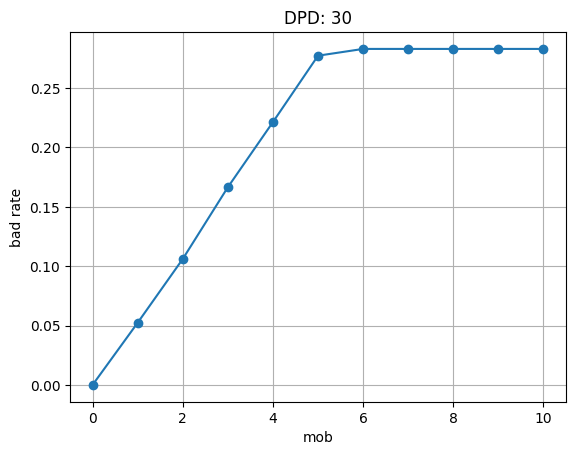

In [11]:
# set dpd label definition
dpd = 30

# Path to the folder containing CSV files
folder_path = silver_loan_daily_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


In [67]:
df.show()

NameError: name 'df' is not defined

In [ ]:
df.select("loan_id", "mob", "dpd", "dpd_flag").show()

## Build Gold Table for Labels & Features

In [13]:
# Create Gold Datalake
gold_label_store_directory = "datamart/gold/label_store/"
gold_feature_store_directory = "datamart/gold/feature_store/"

gold_directories =[gold_label_store_directory, gold_feature_store_directory]

for d in gold_directories:
    if not os.path.exists(d):
        os.makedirs(d)

In [14]:
# Run Gold Backfill
# Note that the MoB was added already during the EDA process in this assignment (to prove what was explained in the class)
# so the code will be slightly different as MoB already there and looking at the chart during EDA, 
# we will use MOB = 6 as reference (stable) so silver datamart on loan/lms doesn't need to be loaded
# another reason is all fields in loan/lms datamart is a post or outcome after the loan is given
# In reality, we won't have this information in hand for ML computation

# New feature introduced:
# 1. has_clickstream, instead of drop all customer that doesn't have clickstream feature this flag is used to identify. The lack of
#    clickstream feature could indicate the user apply it off-line or via different channel (this worth to clarify later)
# 2. Age bucket, instead of giving series of ages to ML, we'll provide bucket/bin of ages range based on the person age lifecycle.

for date_str in dates_str_lst:
    utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6)

for date_str in dates_str_lst:    
    utils.data_processing_gold_table.process_features_gold_table(date_str, gold_label_store_directory, silver_clickstream_directory, \
                                                               silver_attributes_directory, silver_financials_directory, \
                                                               gold_feature_store_directory, spark, mob = 6)


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530
saved to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031
saved to: datamart/gold/label_store/gold_label_store_2023_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet row count: 1537
saved to: datamart/gold/label_store/gold_label_store_2023_03_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet row count: 2047
saved to: datamart/gold/label_store/gold_label_store_2023_04_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet row count: 2568
saved to: datamart/gold/label_store/gold_label_store_2023_05_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet row count: 3085
saved to: datamart/gold/label_store/gold_label_store_2023_06_01.parquet
loaded from

In [15]:
utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6).dtypes


loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531
saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet


[('loan_id', 'string'),
 ('Customer_ID', 'string'),
 ('label', 'int'),
 ('label_def', 'string'),
 ('snapshot_date', 'date')]

## inspect label store

In [16]:
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 8974
+--------------------+-----------+-----+----------+-------------+
|             loan_id|Customer_ID|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x1037_2023_0...| CUS_0x1037|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1069_2023_0...| CUS_0x1069|    0|30dpd_6mob|   2023-07-01|
|CUS_0x114a_2023_0...| CUS_0x114a|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1184_2023_0...| CUS_0x1184|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1297_2023_0...| CUS_0x1297|    1|30dpd_6mob|   2023-07-01|
|CUS_0x12fb_2023_0...| CUS_0x12fb|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1325_2023_0...| CUS_0x1325|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1341_2023_0...| CUS_0x1341|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1375_2023_0...| CUS_0x1375|    1|30dpd_6mob|   2023-07-01|
|CUS_0x13a8_2023_0...| CUS_0x13a8|    0|30dpd_6mob|   2023-07-01|
|CUS_0x13ef_2023_0...| CUS_0x13ef|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1440_2023_0...| CUS_0x1440|    0|30dpd_6mob|   2023-0

In [17]:
df.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

